In [2]:
# Install rpy2 to enable R in Colab
%pip install rpy2==3.5.1

# Load the rpy2.ipython extension
%load_ext rpy2.ipython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.7/201.7 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rpy2: filename=rpy2-3.5.1-cp312-cp312-linux_x86_64.whl size=316568 sha256=59ed83656fe0ce0aabaa59d799d03c7e12d5fa5877cbffc28d5718181d52314a
  Stored in directory: /root/.cache/pip/wheels/00/26/d5/d5e8c0b039915e785be870270e4a9263e5058168a03513d8cc
Successfully built rpy2
  Attempting uninstall: rpy2
    Found existing installation: rpy2 3.5.17
    Uninstalling rpy2-3.5.17:
      Successfully uninstalled rpy2-3.5.17


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

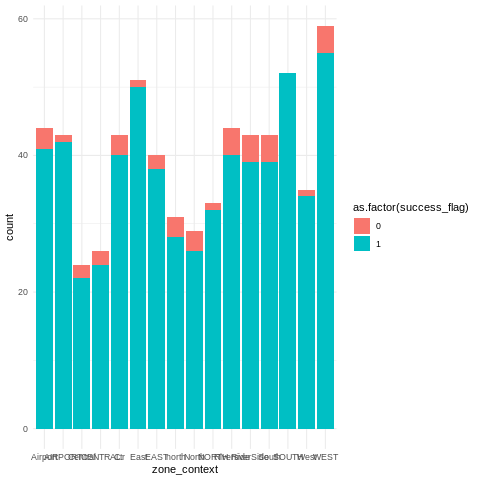

In [11]:
%%R
data <- read.csv("/content/app_events.csv")

summary(data)

table(data$zone_context, data$success_flag)

ggplot(data, aes(x=zone_context, fill=as.factor(success_flag))) +
  geom_bar() +
  theme_minimal()

In [17]:
%%R
sqldf("
SELECT *
FROM data
WHERE api_latency_ms > 1000
")

   event_id customer_id order_id     event_timestamp
1   AE00003       C0494   O00170 2025-08-11 09:29:00
2   AE00031       C0241   O01158 2024-06-09 05:13:00
3   AE00076       C0221   O01006 2025-04-19 07:46:00
4   AE00108       C0307          2024-11-27 16:15:00
5   AE00120       C0429   O00367 2024-08-09 08:11:00
6   AE00123       C0250   O00011 2024-11-15 06:53:00
7   AE00143       C0025   O00124 2024-07-18 18:59:00
8   AE00151       C0472   O00129 2024-11-24 20:48:00
9   AE00193       C0558   O00320 2024-08-10 19:31:00
10  AE00220       C0469   O00413 2025-10-02 15:05:00
11  AE00265       C0192   O01137 2024-11-06 03:00:00
12  AE00282       C0234          2024-08-08 19:03:00
13  AE00293       C0073   O00609 2024-07-10 13:17:00
14  AE00353       C0467   O01164 2025-06-19 03:46:00
15  AE00361       C0107   O01138 2024-08-11 22:50:00
16  AE00387       C0430          2024-12-23 11:44:00
17  AE00389       C0026   O00884 2024-07-14 21:54:00
18  AE00396       C0564   O00111 2024-01-02 03

In [16]:
%%R
sqldf("
SELECT device_type, AVG(success_flag) AS success_rate
FROM data
GROUP BY device_type
")

  device_type success_rate
1     Android    0.9333333
2         Web    0.9347826
3         iOS    0.9527897


In [15]:
%%R
sqldf("
SELECT zone_context, COUNT(*) AS failures
FROM data
WHERE success_flag = 0
GROUP BY zone_context
")

   zone_context failures
1       AIRPORT        1
2       Airport        3
3       CENTRAL        2
4       Central        2
5           Ctr        3
6          EAST        2
7          East        1
8         NORTH        1
9         North        3
10    RiverSide        4
11    Riverside        4
12        South        4
13         WEST        4
14         West        1
15        north        3


In [14]:
%%R
sqldf("
SELECT zone_context, AVG(api_latency_ms) AS avg_latency
FROM data
GROUP BY zone_context
ORDER BY avg_latency DESC
")

   zone_context avg_latency
1       AIRPORT    666.6512
2       Airport    546.8864
3       Central    522.1667
4       CENTRAL    515.2692
5           Ctr    489.3488
6         north    466.8065
7          EAST    460.0750
8         North    452.5172
9          West    443.5429
10        South    440.4884
11    Riverside    424.9091
12        SOUTH    418.5385
13         WEST    416.9322
14    RiverSide    416.8837
15        NORTH    415.8788
16         East    414.8235


In [13]:
%%R
install.packages("sqldf")
library(sqldf)

(as ‘lib’ is unspecified)









	‘/tmp/RtmpTxix3y/downloaded_packages’






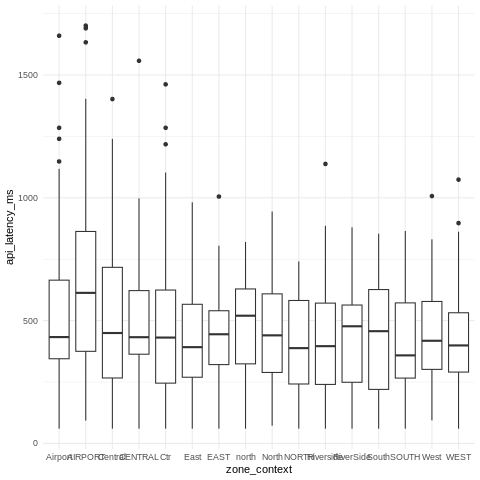

In [12]:
%%R
ggplot(data, aes(x=zone_context, y=api_latency_ms)) +
  geom_boxplot() +
  theme_minimal()

In [10]:
%%R
install.packages("ggplot2")
library(ggplot2)

(as ‘lib’ is unspecified)







	‘/tmp/RtmpTxix3y/downloaded_packages’



In [9]:
%%R
aggregate(api_latency_ms ~ zone_context, data, mean)

   zone_context api_latency_ms
1       Airport       546.8864
2       AIRPORT       666.6512
3       Central       522.1667
4       CENTRAL       515.2692
5           Ctr       489.3488
6          East       414.8235
7          EAST       460.0750
8         north       466.8065
9         North       452.5172
10        NORTH       415.8788
11    Riverside       424.9091
12    RiverSide       416.8837
13        South       440.4884
14        SOUTH       418.5385
15         West       443.5429
16         WEST       416.9322


In [8]:
%%R
table(data$zone_context, data$success_flag)

           
             0  1
  Airport    3 41
  AIRPORT    1 42
  Central    2 22
  CENTRAL    2 24
  Ctr        3 40
  East       1 50
  EAST       2 38
  north      3 28
  North      3 26
  NORTH      1 32
  Riverside  4 40
  RiverSide  4 39
  South      4 39
  SOUTH      0 52
  West       1 34
  WEST       4 55
